Add Baseline GPU Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs("results/figures", exist_ok=True)
# Approximate A100 FP16 specs
peak_flops = 312e12       # 312 TFLOPS
peak_bandwidth = 1.6e12   # 1.6 TB/s

In [4]:
# ===== DAY 3 SETUP BLOCK =====

import numpy as np
import matplotlib.pyplot as plt
import os

# GPU parameters
peak_flops = 312e12
peak_bandwidth = 1.6e12

# Model parameters
d = 1024
bytes_fp16 = 2
bytes_int8 = 1

# Sequence lengths
seq_lengths = [128, 256, 512, 1024, 2048]

# Define AI functions
def attention_ai(T, d, bytes_per_elem):
    flops = 2 * (T**2) * d
    bytes_moved = 3 * T * d * bytes_per_elem
    return flops / bytes_moved

def ffn_ai(T, d, bytes_per_elem):
    flops = 8 * T * (d**2)
    bytes_moved = 4 * T * d * bytes_per_elem
    return flops / bytes_moved

# Compute AI arrays
ai_attention_fp16 = []
ai_attention_int8 = []
ai_ffn_fp16 = []

for T in seq_lengths:
    ai_attention_fp16.append(attention_ai(T, d, bytes_fp16))
    ai_attention_int8.append(attention_ai(T, d, bytes_int8))
    ai_ffn_fp16.append(ffn_ai(T, d, bytes_fp16))

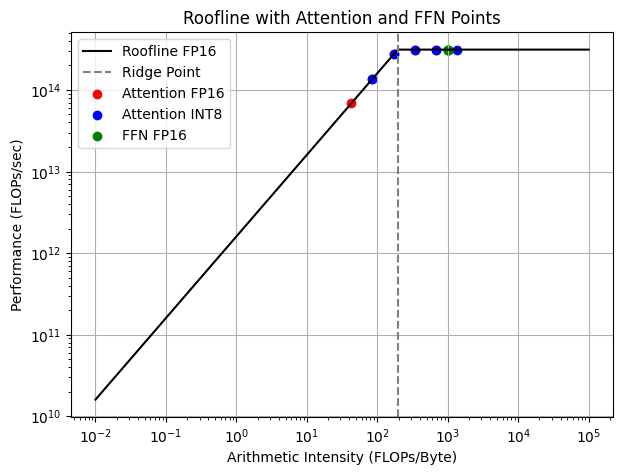

In [5]:
# Recompute roofline range
AI_range = np.logspace(-2, 5, 500)
roof = np.minimum(peak_flops, AI_range * peak_bandwidth)

plt.figure(figsize=(7,5))
plt.loglog(AI_range, roof, label="Roofline FP16", color="black")

ridge_point = peak_flops / peak_bandwidth
plt.axvline(ridge_point, color='gray', linestyle='--', label="Ridge Point")

# Plot Attention FP16 points
plt.scatter(ai_attention_fp16,
            [min(peak_flops, ai * peak_bandwidth) for ai in ai_attention_fp16],
            color="red", marker='o', label="Attention FP16")

# Plot Attention INT8 points (rightward shift)
plt.scatter(ai_attention_int8,
            [min(peak_flops, ai * peak_bandwidth) for ai in ai_attention_int8],
            color="blue", marker='o', label="Attention INT8")

# Plot FFN FP16 points
plt.scatter(ai_ffn_fp16,
            [min(peak_flops, ai * peak_bandwidth) for ai in ai_ffn_fp16],
            color="green", marker='o', label="FFN FP16")

plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
plt.ylabel("Performance (FLOPs/sec)")
plt.title("Roofline with Attention and FFN Points")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/roofline_with_points.png", dpi=300)
plt.show()

Plot Baseline Roofline

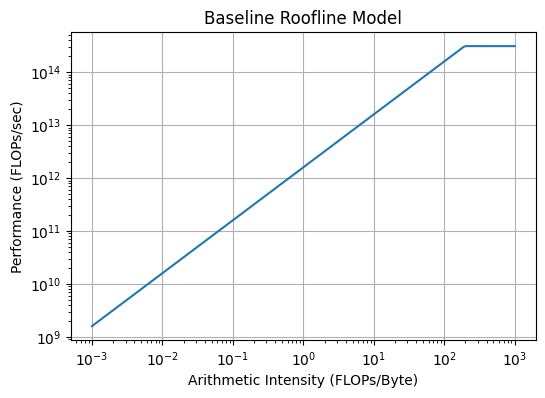

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

AI = np.logspace(-3, 3, 200)
roof = np.minimum(peak_flops, AI * peak_bandwidth)

plt.figure(figsize=(6,4))
plt.loglog(AI, roof)
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
plt.ylabel("Performance (FLOPs/sec)")
plt.title("Baseline Roofline Model")
plt.grid(True)
plt.savefig("results/figures/baseline_roofline.png", dpi=300, bbox_inches="tight")
plt.show()

Save the plot

In [7]:
# Model parameters
d = 1024
bytes_fp16 = 2
bytes_int8 = 1

# Sequence lengths
seq_lengths = [128, 256, 512, 1024, 2048]

# Define AI functions
def attention_ai(T, d, bytes_per_elem):
    flops = 2 * (T**2) * d
    bytes_moved = 3 * T * d * bytes_per_elem
    return flops / bytes_moved

def ffn_ai(T, d, bytes_per_elem):
    flops = 8 * T * (d**2)
    bytes_moved = 4 * T * d * bytes_per_elem
    return flops / bytes_moved

# Compute AI arrays
ai_attention_fp16 = []
ai_attention_int8 = []
ai_ffn_fp16 = []

for T in seq_lengths:
    ai_attention_fp16.append(attention_ai(T, d, bytes_fp16))
    ai_attention_int8.append(attention_ai(T, d, bytes_int8))
    ai_ffn_fp16.append(ffn_ai(T, d, bytes_fp16))

AI vs Sequence Length

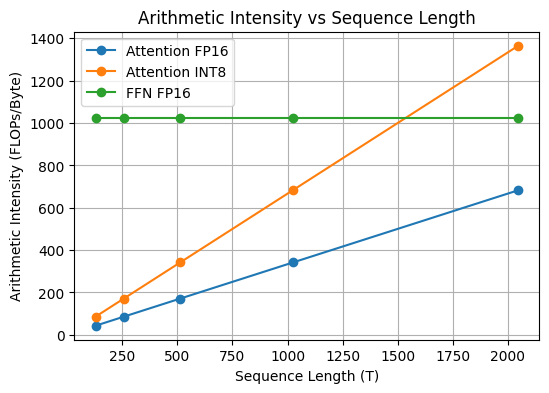

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))

plt.plot(seq_lengths, ai_attention_fp16, marker='o', label="Attention FP16")
plt.plot(seq_lengths, ai_attention_int8, marker='o', label="Attention INT8")
plt.plot(seq_lengths, ai_ffn_fp16, marker='o', label="FFN FP16")

plt.xlabel("Sequence Length (T)")
plt.ylabel("Arithmetic Intensity (FLOPs/Byte)")
plt.title("Arithmetic Intensity vs Sequence Length")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/ai_vs_seq.png", dpi=300)
plt.show()